In [ ]:
# We will use SKLEARN to implement NB
# we will use TFIDF (Term Frequecy * Inverse Document Frequency) -> Feature Enginnering -> Weights to train the model
# Class 0-> SPAM, 1 -> HAM(Normal Email)
# MLOPS : To understand model output and efficacy

In [1]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve
)
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import re

In [2]:
class SpamFilterNaiveBayes:
    """
    Spam Filter using Multinomial Naive Bayes with TF-IDF features.
    """

    def __init__(self, max_features=5000, ngram_range=(1, 2), min_df=2):
        """
        Initialize the spam filter.

        Parameters:
        -----------
        max_features : int
            Maximum number of features for TF-IDF
        ngram_range : tuple
            Range of n-grams to extract (1,1) for unigrams, (1,2) for unigrams+bigrams
        min_df : int
            Minimum document frequency for a term to be included
        """
        self.vectorizer = TfidfVectorizer(
            max_features=max_features,
            ngram_range=ngram_range,
            min_df=min_df,
            stop_words='english',
            lowercase=True,
            strip_accents='unicode'
        )
        self.classifier = MultinomialNB(alpha=1.0)
        self.is_fitted = False

    def preprocess_text(self, text):
        """
        Basic text preprocessing.

        Parameters:
        -----------
        text : str
            Input text to preprocess

        Returns:
        --------
        str : Preprocessed text
        """
        # Convert to lowercase
        text = text.lower()

        # Remove URLs
        text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)

        # Remove email addresses
        text = re.sub(r'\S+@\S+', '', text)

        # Remove extra whitespace
        text = re.sub(r'\s+', ' ', text).strip()

        return text

    def fit(self, X_train, y_train):
        """
        Train the spam filter.

        Parameters:
        -----------
        X_train : array-like
            Training text data
        y_train : array-like
            Training labels (0 for ham, 1 for spam)
        """
        # Preprocess texts
        X_train_processed = [self.preprocess_text(text) for text in X_train]

        # Transform to TF-IDF features
        X_train_tfidf = self.vectorizer.fit_transform(X_train_processed)

        # Train the classifier
        self.classifier.fit(X_train_tfidf, y_train)
        self.is_fitted = True

        print(f"Model trained successfully!")
        print(f"Vocabulary size: {len(self.vectorizer.vocabulary_)}")
        print(f"Training samples: {len(X_train)}")

    def predict(self, X_test):
        """
        Predict labels for test data.

        Parameters:
        -----------
        X_test : array-like
            Test text data

        Returns:
        --------
        array : Predicted labels
        """
        if not self.is_fitted:
            raise ValueError("Model must be fitted before prediction!")

        # Preprocess texts
        X_test_processed = [self.preprocess_text(text) for text in X_test]

        # Transform to TF-IDF features
        X_test_tfidf = self.vectorizer.transform(X_test_processed)

        # Predict
        return self.classifier.predict(X_test_tfidf)

    def predict_proba(self, X_test):
        """
        Predict probability scores for test data.

        Parameters:
        -----------
        X_test : array-like
            Test text data

        Returns:
        --------
        array : Probability scores for each class
        """
        if not self.is_fitted:
            raise ValueError("Model must be fitted before prediction!")

        # Preprocess texts
        X_test_processed = [self.preprocess_text(text) for text in X_test]

        # Transform to TF-IDF features
        X_test_tfidf = self.vectorizer.transform(X_test_processed)

        # Predict probabilities
        return self.classifier.predict_proba(X_test_tfidf)

    def get_top_features(self, n=20, class_label=1):
        """
        Get top n most important features for a class.

        Parameters:
        -----------
        n : int
            Number of top features to return
        class_label : int
            Class label (0 for ham, 1 for spam)

        Returns:
        --------
        list : Top n features with their log probabilities
        """
        if not self.is_fitted:
            raise ValueError("Model must be fitted first!")

        feature_names = self.vectorizer.get_feature_names_out()
        log_probs = self.classifier.feature_log_prob_[class_label]

        top_indices = np.argsort(log_probs)[-n:][::-1]
        top_features = [(feature_names[i], log_probs[i]) for i in top_indices]

        return top_features


In [3]:
def create_sample_dataset():
    """
    Create a sample spam/ham dataset for demonstration.

    Returns:
    --------
    tuple : (texts, labels)
    """
    spam_messages = [
        "WINNER!! You have won a $1000 Walmart gift card. Click here to claim now!",
        "Congratulations! You've been selected for a free iPhone. Call now!",
        "URGENT: Your account has been compromised. Verify your identity immediately.",
        "Make money fast! Work from home and earn $5000 per week!",
        "Limited time offer! Buy viagra online at discount prices!",
        "You have won the lottery! Send your bank details to claim prize.",
        "Get rich quick with this amazing investment opportunity!",
        "Free credit check! No obligations! Apply now!",
        "CONGRATULATIONS! You are the lucky winner of our prize draw!",
        "Claim your free gift card worth $500 today only!",
        "Lose weight fast with this miracle pill! Order now!",
        "Work from home and make thousands! No experience needed!",
        "Your computer has a virus! Download our antivirus now!",
        "Meet singles in your area! Sign up for free!",
        "Earn extra income working part-time from home!",
        "Get approved for a loan instantly! Bad credit OK!",
        "Click here to unsubscribe from these amazing offers!",
        "Buy prescription drugs online without prescription!",
        "Enlarge your assets with our proven method!",
        "Act now! Limited stock available! Don't miss out!"
    ]

    ham_messages = [
        "Hey, are we still meeting for lunch tomorrow at 1pm?",
        "Thanks for your email. I'll review the document and get back to you.",
        "The project deadline has been moved to next Friday.",
        "Can you send me the presentation slides from yesterday's meeting?",
        "I'll be working from home tomorrow. Let me know if you need anything.",
        "Great job on the report! The client was very impressed.",
        "Don't forget we have a team meeting at 3pm today.",
        "I've attached the updated budget spreadsheet for your review.",
        "Could you please approve my vacation request for next month?",
        "The conference call has been rescheduled to Tuesday at 10am.",
        "I need your input on the proposal before we submit it.",
        "Thank you for your help with the presentation yesterday.",
        "The training session will be held in conference room B.",
        "Please review the attached contract and let me know your thoughts.",
        "I'll send you the meeting notes by end of day.",
        "Can we schedule a call to discuss the project timeline?",
        "Your package has been delivered to the front desk.",
        "Reminder: Staff meeting tomorrow at 9am in the main office.",
        "I've completed the analysis you requested. See attached file.",
        "Let's touch base next week to discuss the quarterly results."
    ]

    # Create dataset
    texts = spam_messages + ham_messages
    labels = [1] * len(spam_messages) + [0] * len(ham_messages)

    return texts, labels

In [4]:
def evaluate_model(model, X_test, y_test):
    """
    Evaluate the model and display comprehensive metrics.

    Parameters:
    -----------
    model : SpamFilterNaiveBayes
        Trained spam filter model
    X_test : array-like
        Test text data
    y_test : array-like
        True labels
    """
    # Make predictions
    y_pred = model.predict(X_test)
    y_pred_proba = model.predict_proba(X_test)[:, 1]

    # Calculate metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    print("\n" + "="*60)
    print("MODEL EVALUATION METRICS")
    print("="*60)
    print(f"Accuracy:  {accuracy:.4f}")
    print(f"Precision: {precision:.4f} (spam predictions that were correct)")
    print(f"Recall:    {recall:.4f} (spam messages that were caught)")
    print(f"F1-Score:  {f1:.4f}")

    # Classification report
    print("\n" + "-"*60)
    print("DETAILED CLASSIFICATION REPORT")
    print("-"*60)
    print(classification_report(y_test, y_pred, target_names=['Ham', 'Spam']))

    # Confusion matrix
    cm = confusion_matrix(y_test, y_pred)
    print("\n" + "-"*60)
    print("CONFUSION MATRIX")
    print("-"*60)
    print(f"True Negatives (Ham correctly classified):  {cm[0, 0]}")
    print(f"False Positives (Ham misclassified as Spam): {cm[0, 1]}")
    print(f"False Negatives (Spam misclassified as Ham): {cm[1, 0]}")
    print(f"True Positives (Spam correctly classified): {cm[1, 1]}")

    # Plot confusion matrix
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Ham', 'Spam'],
                yticklabels=['Ham', 'Spam'])
    plt.title('Confusion Matrix')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.tight_layout()
    plt.savefig('/mnt/user-data/outputs/confusion_matrix.png', dpi=300, bbox_inches='tight')
    print("\n✓ Confusion matrix plot saved!")

    # ROC curve
    if len(np.unique(y_test)) > 1:
        auc_score = roc_auc_score(y_test, y_pred_proba)
        fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)

        plt.figure(figsize=(8, 6))
        plt.plot(fpr, tpr, color='darkorange', lw=2,
                label=f'ROC curve (AUC = {auc_score:.4f})')
        plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Classifier')
        plt.xlim([0.0, 1.0])
        plt.ylim([0.0, 1.05])
        plt.xlabel('False Positive Rate')
        plt.ylabel('True Positive Rate')
        plt.title('Receiver Operating Characteristic (ROC) Curve')
        plt.legend(loc="lower right")
        plt.grid(alpha=0.3)
        plt.tight_layout()
        plt.savefig('/mnt/user-data/outputs/roc_curve.png', dpi=300, bbox_inches='tight')
        print("✓ ROC curve plot saved!")
        print(f"\nAUC-ROC Score: {auc_score:.4f}")


In [5]:
def display_top_features(model, n=15):
    """
    Display top features for spam and ham classes.

    Parameters:
    -----------
    model : SpamFilterNaiveBayes
        Trained spam filter model
    n : int
        Number of top features to display
    """
    print("\n" + "="*60)
    print("TOP FEATURES ANALYSIS")
    print("="*60)

    # Top spam features
    print(f"\nTop {n} SPAM indicators:")
    print("-"*60)
    spam_features = model.get_top_features(n=n, class_label=1)
    for i, (feature, score) in enumerate(spam_features, 1):
        print(f"{i:2d}. {feature:30s} (log-prob: {score:.4f})")

    # Top ham features
    print(f"\nTop {n} HAM indicators:")
    print("-"*60)
    ham_features = model.get_top_features(n=n, class_label=0)
    for i, (feature, score) in enumerate(ham_features, 1):
        print(f"{i:2d}. {feature:30s} (log-prob: {score:.4f})")

    # Visualize top features
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

    # Spam features
    spam_words = [f[0] for f in spam_features]
    spam_scores = [np.exp(f[1]) for f in spam_features]
    ax1.barh(range(len(spam_words)), spam_scores, color='red', alpha=0.7)
    ax1.set_yticks(range(len(spam_words)))
    ax1.set_yticklabels(spam_words)
    ax1.set_xlabel('Probability')
    ax1.set_title(f'Top {n} SPAM Features')
    ax1.invert_yaxis()

    # Ham features
    ham_words = [f[0] for f in ham_features]
    ham_scores = [np.exp(f[1]) for f in ham_features]
    ax2.barh(range(len(ham_words)), ham_scores, color='green', alpha=0.7)
    ax2.set_yticks(range(len(ham_words)))
    ax2.set_yticklabels(ham_words)
    ax2.set_xlabel('Probability')
    ax2.set_title(f'Top {n} HAM Features')
    ax2.invert_yaxis()

    plt.tight_layout()
    plt.savefig('/mnt/user-data/outputs/top_features.png', dpi=300, bbox_inches='tight')
    print("\n✓ Top features visualization saved!")


def test_custom_messages(model):
    """
    Test the model with custom messages.

    Parameters:
    -----------
    model : SpamFilterNaiveBayes
        Trained spam filter model
    """
    test_messages = [
        "Congratulations! You've won a free prize!",
        "Can we reschedule our meeting to next week?",
        "CLICK HERE for amazing deals!!!",
        "I've reviewed your proposal and have some feedback.",
        "Get rich quick! Make $10000 in one week!",
        "Please find the attached report for your review."
    ]

    print("\n" + "="*60)
    print("TESTING CUSTOM MESSAGES")
    print("="*60)

    predictions = model.predict(test_messages)
    probabilities = model.predict_proba(test_messages)

    for i, (msg, pred, proba) in enumerate(zip(test_messages, predictions, probabilities), 1):
        label = "SPAM" if pred == 1 else "HAM"
        confidence = proba[pred] * 100
        print(f"\n{i}. Message: \"{msg[:60]}...\"" if len(msg) > 60 else f"\n{i}. Message: \"{msg}\"")
        print(f"   Prediction: {label} (Confidence: {confidence:.2f}%)")

SPAM FILTER USING NAIVE BAYES WITH TF-IDF

1. Loading dataset...
   Total messages: 40
   Spam messages: 20
   Ham messages: 20

2. Splitting data into train/test sets...
   Training samples: 30
   Test samples: 10

3. Training Naive Bayes classifier...
Model trained successfully!
Vocabulary size: 267
Training samples: 30

4. Evaluating model performance...

MODEL EVALUATION METRICS
Accuracy:  0.9000
Precision: 0.8333 (spam predictions that were correct)
Recall:    1.0000 (spam messages that were caught)
F1-Score:  0.9091

------------------------------------------------------------
DETAILED CLASSIFICATION REPORT
------------------------------------------------------------
              precision    recall  f1-score   support

         Ham       1.00      0.80      0.89         5
        Spam       0.83      1.00      0.91         5

    accuracy                           0.90        10
   macro avg       0.92      0.90      0.90        10
weighted avg       0.92      0.90      0.90   

FileNotFoundError: [Errno 2] No such file or directory: '/mnt/user-data/outputs/confusion_matrix.png'

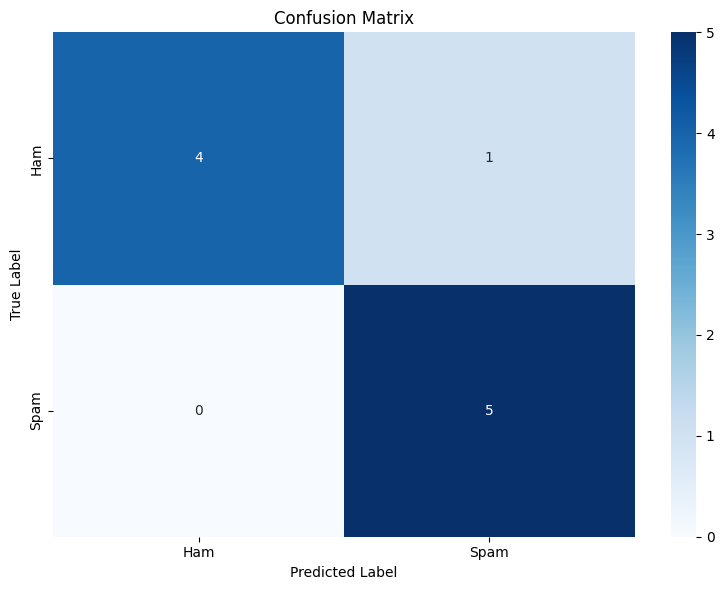

In [7]:
def main():
    """
    Main function to run the spam filter demonstration.
    """
    print("="*60)
    print("SPAM FILTER USING NAIVE BAYES WITH TF-IDF")
    print("="*60)

    # Create or load dataset
    print("\n1. Loading dataset...")
    texts, labels = create_sample_dataset()

    # print(f"   Total messages: {len(texts)}")
    # print(f"   Spam messages: {sum(labels)}")
    # print(f"   Ham messages: {len(labels) - sum(labels)}")

    # Split data
    print("\n2. Splitting data into train/test sets...")
    X_train, X_test, y_train, y_test = train_test_split(
        texts, labels, test_size=0.25, random_state=42, stratify=labels
    )
    print(f"   Training samples: {len(X_train)}")
    print(f"   Test samples: {len(X_test)}")

    # Initialize and train model
    print("\n3. Training Naive Bayes classifier...")
    spam_filter = SpamFilterNaiveBayes(
        max_features=1000,
        ngram_range=(1, 2),
        min_df=1
    )
    spam_filter.fit(X_train, y_train)

    # Evaluate model
    print("\n4. Evaluating model performance...")
    evaluate_model(spam_filter, X_test, y_test)

    # Display top features
    display_top_features(spam_filter, n=15)

    # Test custom messages
    test_custom_messages(spam_filter)

    print("\n" + "="*60)
    print("ANALYSIS COMPLETE!")
    print("="*60)
    print("\nGenerated files:")
    #print("  • confusion_matrix.png")
    #print("  • roc_curve.png")
    #print("  • top_features.png")


if __name__ == "__main__":
    main()


SPAM FILTER USING NAIVE BAYES WITH TF-IDF

1. Loading dataset...
   Total messages: 40
   Spam messages: 20
   Ham messages: 20

2. Splitting data into train/test sets...
   Training samples: 30
   Test samples: 10

3. Training Naive Bayes classifier...
Model trained successfully!
Vocabulary size: 267
Training samples: 30

4. Evaluating model performance...

MODEL EVALUATION METRICS
Accuracy:  0.9000
Precision: 0.8333 (spam predictions that were correct)
Recall:    1.0000 (spam messages that were caught)
F1-Score:  0.9091

------------------------------------------------------------
DETAILED CLASSIFICATION REPORT
------------------------------------------------------------
              precision    recall  f1-score   support

         Ham       1.00      0.80      0.89         5
        Spam       0.83      1.00      0.91         5

    accuracy                           0.90        10
   macro avg       0.92      0.90      0.90        10
weighted avg       0.92      0.90      0.90   

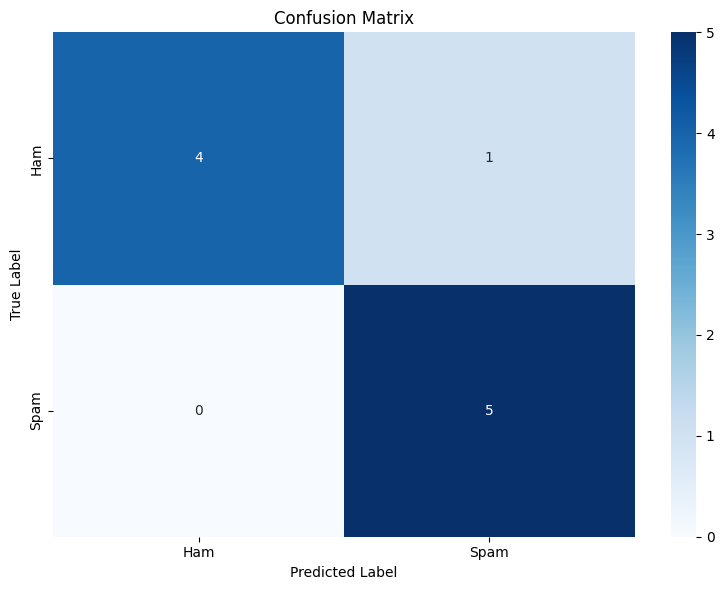

✓ ROC curve saved to: ./roc_curve.png


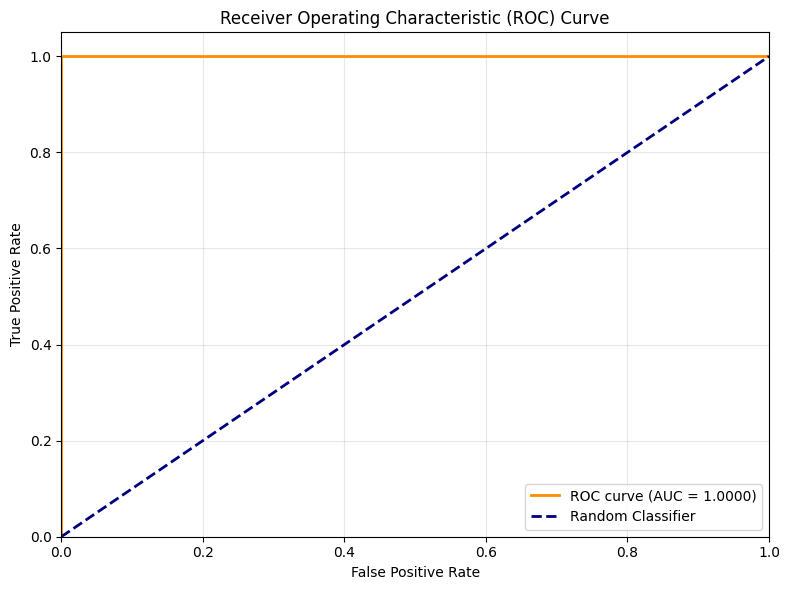


AUC-ROC Score: 1.0000

TOP FEATURES ANALYSIS

Top 15 SPAM indicators:
------------------------------------------------------------
 1. free                           (log-prob: -5.1730)
 2. amazing                        (log-prob: -5.2576)
 3. credit                         (log-prob: -5.2978)
 4. earn                           (log-prob: -5.3358)
 5. time                           (log-prob: -5.3387)
 6. fast                           (log-prob: -5.3423)
 7. limited                        (log-prob: -5.3453)
 8. claim                          (log-prob: -5.3459)
 9. home                           (log-prob: -5.3657)
10. click unsubscribe              (log-prob: -5.4292)
11. unsubscribe amazing            (log-prob: -5.4292)
12. amazing offers                 (log-prob: -5.4292)
13. click                          (log-prob: -5.4292)
14. offers                         (log-prob: -5.4292)
15. unsubscribe                    (log-prob: -5.4292)

Top 15 HAM indicators:
-------------------

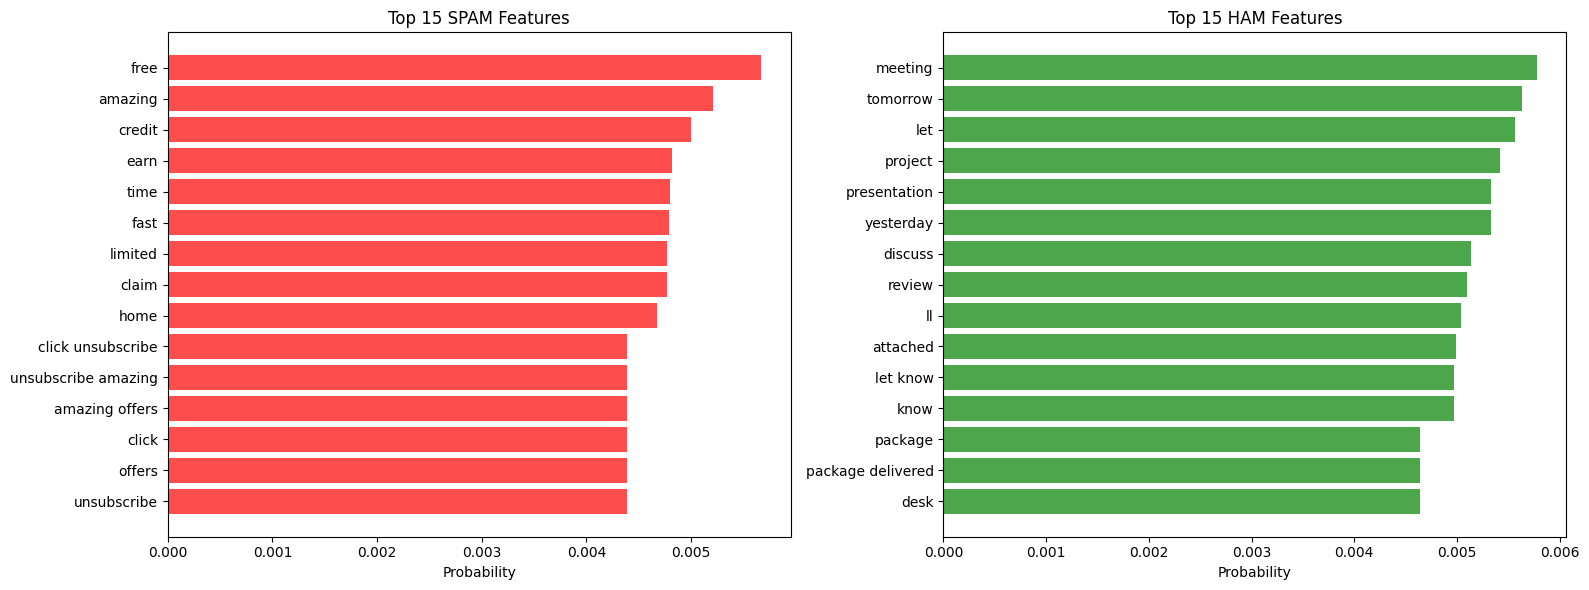


TESTING CUSTOM MESSAGES

1. Message: "Congratulations! You've won a free prize!"
   Prediction: SPAM (Confidence: 58.54%)

2. Message: "Can we reschedule our meeting to next week?"
   Prediction: HAM (Confidence: 60.42%)

3. Message: "CLICK HERE for amazing deals!!!"
   Prediction: SPAM (Confidence: 63.57%)

4. Message: "I've reviewed your proposal and have some feedback."
   Prediction: HAM (Confidence: 56.88%)

5. Message: "Get rich quick! Make $10000 in one week!"
   Prediction: SPAM (Confidence: 61.66%)

6. Message: "Please find the attached report for your review."
   Prediction: HAM (Confidence: 66.81%)

ANALYSIS COMPLETE!

Output files saved to: /Users/anoopchemencherry/Documents/IITAI/PYNB/Week16
  • confusion_matrix.png
  • roc_curve.png
  • top_features.png


In [1]:
"""
Spam Filter using Naive Bayes with TF-IDF - Google Colab Version
=================================================================
This implementation demonstrates spam classification using:
- TF-IDF vectorization for feature extraction
- Multinomial Naive Bayes classifier
- Comprehensive evaluation metrics
"""

import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve
)
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import re
import os


class SpamFilterNaiveBayes:
    """
    Spam Filter using Multinomial Naive Bayes with TF-IDF features.
    """

    def __init__(self, max_features=5000, ngram_range=(1, 2), min_df=2):
        """
        Initialize the spam filter.

        Parameters:
        -----------
        max_features : int
            Maximum number of features for TF-IDF
        ngram_range : tuple
            Range of n-grams to extract (1,1) for unigrams, (1,2) for unigrams+bigrams
        min_df : int
            Minimum document frequency for a term to be included
        """
        self.vectorizer = TfidfVectorizer(
            max_features=max_features,
            ngram_range=ngram_range,
            min_df=min_df,
            stop_words='english',
            lowercase=True,
            strip_accents='unicode'
        )
        self.classifier = MultinomialNB(alpha=1.0)
        self.is_fitted = False

    def preprocess_text(self, text):
        """
        Basic text preprocessing.

        Parameters:
        -----------
        text : str
            Input text to preprocess

        Returns:
        --------
        str : Preprocessed text
        """
        # Convert to lowercase
        text = text.lower()

        # Remove URLs
        text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)

        # Remove email addresses
        text = re.sub(r'\S+@\S+', '', text)

        # Remove extra whitespace
        text = re.sub(r'\s+', ' ', text).strip()

        return text

    def fit(self, X_train, y_train):
        """
        Train the spam filter.

        Parameters:
        -----------
        X_train : array-like
            Training text data
        y_train : array-like
            Training labels (0 for ham, 1 for spam)
        """
        # Preprocess texts
        X_train_processed = [self.preprocess_text(text) for text in X_train]

        # Transform to TF-IDF features
        X_train_tfidf = self.vectorizer.fit_transform(X_train_processed)

        # Train the classifier
        self.classifier.fit(X_train_tfidf, y_train)
        self.is_fitted = True

        print(f"Model trained successfully!")
        print(f"Vocabulary size: {len(self.vectorizer.vocabulary_)}")
        print(f"Training samples: {len(X_train)}")

    def predict(self, X_test):
        """
        Predict labels for test data.

        Parameters:
        -----------
        X_test : array-like
            Test text data

        Returns:
        --------
        array : Predicted labels
        """
        if not self.is_fitted:
            raise ValueError("Model must be fitted before prediction!")

        # Preprocess texts
        X_test_processed = [self.preprocess_text(text) for text in X_test]

        # Transform to TF-IDF features
        X_test_tfidf = self.vectorizer.transform(X_test_processed)

        # Predict
        return self.classifier.predict(X_test_tfidf)

    def predict_proba(self, X_test):
        """
        Predict probability scores for test data.

        Parameters:
        -----------
        X_test : array-like
            Test text data

        Returns:
        --------
        array : Probability scores for each class
        """
        if not self.is_fitted:
            raise ValueError("Model must be fitted before prediction!")

        # Preprocess texts
        X_test_processed = [self.preprocess_text(text) for text in X_test]

        # Transform to TF-IDF features
        X_test_tfidf = self.vectorizer.transform(X_test_processed)

        # Predict probabilities
        return self.classifier.predict_proba(X_test_tfidf)

    def get_top_features(self, n=20, class_label=1):
        """
        Get top n most important features for a class.

        Parameters:
        -----------
        n : int
            Number of top features to return
        class_label : int
            Class label (0 for ham, 1 for spam)

        Returns:
        --------
        list : Top n features with their log probabilities
        """
        if not self.is_fitted:
            raise ValueError("Model must be fitted first!")

        feature_names = self.vectorizer.get_feature_names_out()
        log_probs = self.classifier.feature_log_prob_[class_label]

        top_indices = np.argsort(log_probs)[-n:][::-1]
        top_features = [(feature_names[i], log_probs[i]) for i in top_indices]

        return top_features


def create_sample_dataset():
    """
    Create a sample spam/ham dataset for demonstration.

    Returns:
    --------
    tuple : (texts, labels)
    """
    spam_messages = [
        "WINNER!! You have won a $1000 Walmart gift card. Click here to claim now!",
        "Congratulations! You've been selected for a free iPhone. Call now!",
        "URGENT: Your account has been compromised. Verify your identity immediately.",
        "Make money fast! Work from home and earn $5000 per week!",
        "Limited time offer! Buy viagra online at discount prices!",
        "You have won the lottery! Send your bank details to claim prize.",
        "Get rich quick with this amazing investment opportunity!",
        "Free credit check! No obligations! Apply now!",
        "CONGRATULATIONS! You are the lucky winner of our prize draw!",
        "Claim your free gift card worth $500 today only!",
        "Lose weight fast with this miracle pill! Order now!",
        "Work from home and make thousands! No experience needed!",
        "Your computer has a virus! Download our antivirus now!",
        "Meet singles in your area! Sign up for free!",
        "Earn extra income working part-time from home!",
        "Get approved for a loan instantly! Bad credit OK!",
        "Click here to unsubscribe from these amazing offers!",
        "Buy prescription drugs online without prescription!",
        "Enlarge your assets with our proven method!",
        "Act now! Limited stock available! Don't miss out!"
    ]

    ham_messages = [
        "Hey, are we still meeting for lunch tomorrow at 1pm?",
        "Thanks for your email. I'll review the document and get back to you.",
        "The project deadline has been moved to next Friday.",
        "Can you send me the presentation slides from yesterday's meeting?",
        "I'll be working from home tomorrow. Let me know if you need anything.",
        "Great job on the report! The client was very impressed.",
        "Don't forget we have a team meeting at 3pm today.",
        "I've attached the updated budget spreadsheet for your review.",
        "Could you please approve my vacation request for next month?",
        "The conference call has been rescheduled to Tuesday at 10am.",
        "I need your input on the proposal before we submit it.",
        "Thank you for your help with the presentation yesterday.",
        "The training session will be held in conference room B.",
        "Please review the attached contract and let me know your thoughts.",
        "I'll send you the meeting notes by end of day.",
        "Can we schedule a call to discuss the project timeline?",
        "Your package has been delivered to the front desk.",
        "Reminder: Staff meeting tomorrow at 9am in the main office.",
        "I've completed the analysis you requested. See attached file.",
        "Let's touch base next week to discuss the quarterly results."
    ]

    # Create dataset
    texts = spam_messages + ham_messages
    labels = [1] * len(spam_messages) + [0] * len(ham_messages)

    return texts, labels


def evaluate_model(model, X_test, y_test, output_dir='.'):
    """
    Evaluate the model and display comprehensive metrics.

    Parameters:
    -----------
    model : SpamFilterNaiveBayes
        Trained spam filter model
    X_test : array-like
        Test text data
    y_test : array-like
        True labels
    output_dir : str
        Directory to save output plots (default: current directory)
    """
    # Create output directory if it doesn't exist
    os.makedirs(output_dir, exist_ok=True)

    # Make predictions
    y_pred = model.predict(X_test)
    y_pred_proba = model.predict_proba(X_test)[:, 1]

    # Calculate metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    print("\n" + "="*60)
    print("MODEL EVALUATION METRICS")
    print("="*60)
    print(f"Accuracy:  {accuracy:.4f}")
    print(f"Precision: {precision:.4f} (spam predictions that were correct)")
    print(f"Recall:    {recall:.4f} (spam messages that were caught)")
    print(f"F1-Score:  {f1:.4f}")

    # Classification report
    print("\n" + "-"*60)
    print("DETAILED CLASSIFICATION REPORT")
    print("-"*60)
    print(classification_report(y_test, y_pred, target_names=['Ham', 'Spam']))

    # Confusion matrix
    cm = confusion_matrix(y_test, y_pred)
    print("\n" + "-"*60)
    print("CONFUSION MATRIX")
    print("-"*60)
    print(f"True Negatives (Ham correctly classified):  {cm[0, 0]}")
    print(f"False Positives (Ham misclassified as Spam): {cm[0, 1]}")
    print(f"False Negatives (Spam misclassified as Ham): {cm[1, 0]}")
    print(f"True Positives (Spam correctly classified): {cm[1, 1]}")

    # Plot confusion matrix
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Ham', 'Spam'],
                yticklabels=['Ham', 'Spam'])
    plt.title('Confusion Matrix')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.tight_layout()

    cm_path = os.path.join(output_dir, 'confusion_matrix.png')
    plt.savefig(cm_path, dpi=300, bbox_inches='tight')
    print(f"\n✓ Confusion matrix saved to: {cm_path}")
    plt.show()

    # ROC curve
    if len(np.unique(y_test)) > 1:
        auc_score = roc_auc_score(y_test, y_pred_proba)
        fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)

        plt.figure(figsize=(8, 6))
        plt.plot(fpr, tpr, color='darkorange', lw=2,
                label=f'ROC curve (AUC = {auc_score:.4f})')
        plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Classifier')
        plt.xlim([0.0, 1.0])
        plt.ylim([0.0, 1.05])
        plt.xlabel('False Positive Rate')
        plt.ylabel('True Positive Rate')
        plt.title('Receiver Operating Characteristic (ROC) Curve')
        plt.legend(loc="lower right")
        plt.grid(alpha=0.3)
        plt.tight_layout()

        roc_path = os.path.join(output_dir, 'roc_curve.png')
        plt.savefig(roc_path, dpi=300, bbox_inches='tight')
        print(f"✓ ROC curve saved to: {roc_path}")
        plt.show()

        print(f"\nAUC-ROC Score: {auc_score:.4f}")


def display_top_features(model, n=15, output_dir='.'):
    """
    Display top features for spam and ham classes.

    Parameters:
    -----------
    model : SpamFilterNaiveBayes
        Trained spam filter model
    n : int
        Number of top features to display
    output_dir : str
        Directory to save output plots
    """
    # Create output directory if it doesn't exist
    os.makedirs(output_dir, exist_ok=True)

    print("\n" + "="*60)
    print("TOP FEATURES ANALYSIS")
    print("="*60)

    # Top spam features
    print(f"\nTop {n} SPAM indicators:")
    print("-"*60)
    spam_features = model.get_top_features(n=n, class_label=1)
    for i, (feature, score) in enumerate(spam_features, 1):
        print(f"{i:2d}. {feature:30s} (log-prob: {score:.4f})")

    # Top ham features
    print(f"\nTop {n} HAM indicators:")
    print("-"*60)
    ham_features = model.get_top_features(n=n, class_label=0)
    for i, (feature, score) in enumerate(ham_features, 1):
        print(f"{i:2d}. {feature:30s} (log-prob: {score:.4f})")

    # Visualize top features
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

    # Spam features
    spam_words = [f[0] for f in spam_features]
    spam_scores = [np.exp(f[1]) for f in spam_features]
    ax1.barh(range(len(spam_words)), spam_scores, color='red', alpha=0.7)
    ax1.set_yticks(range(len(spam_words)))
    ax1.set_yticklabels(spam_words)
    ax1.set_xlabel('Probability')
    ax1.set_title(f'Top {n} SPAM Features')
    ax1.invert_yaxis()

    # Ham features
    ham_words = [f[0] for f in ham_features]
    ham_scores = [np.exp(f[1]) for f in ham_features]
    ax2.barh(range(len(ham_words)), ham_scores, color='green', alpha=0.7)
    ax2.set_yticks(range(len(ham_words)))
    ax2.set_yticklabels(ham_words)
    ax2.set_xlabel('Probability')
    ax2.set_title(f'Top {n} HAM Features')
    ax2.invert_yaxis()

    plt.tight_layout()

    features_path = os.path.join(output_dir, 'top_features.png')
    plt.savefig(features_path, dpi=300, bbox_inches='tight')
    print(f"\n✓ Top features visualization saved to: {features_path}")
    plt.show()


def test_custom_messages(model):
    """
    Test the model with custom messages.

    Parameters:
    -----------
    model : SpamFilterNaiveBayes
        Trained spam filter model
    """
    test_messages = [
        "Congratulations! You've won a free prize!",
        "Can we reschedule our meeting to next week?",
        "CLICK HERE for amazing deals!!!",
        "I've reviewed your proposal and have some feedback.",
        "Get rich quick! Make $10000 in one week!",
        "Please find the attached report for your review."
    ]

    print("\n" + "="*60)
    print("TESTING CUSTOM MESSAGES")
    print("="*60)

    predictions = model.predict(test_messages)
    probabilities = model.predict_proba(test_messages)

    for i, (msg, pred, proba) in enumerate(zip(test_messages, predictions, probabilities), 1):
        label = "SPAM" if pred == 1 else "HAM"
        confidence = proba[pred] * 100
        print(f"\n{i}. Message: \"{msg[:60]}...\"" if len(msg) > 60 else f"\n{i}. Message: \"{msg}\"")
        print(f"   Prediction: {label} (Confidence: {confidence:.2f}%)")


def main(output_dir='.'):
    """
    Main function to run the spam filter demonstration.

    Parameters:
    -----------
    output_dir : str
        Directory to save output files (default: current directory)
    """
    print("="*60)
    print("SPAM FILTER USING NAIVE BAYES WITH TF-IDF")
    print("="*60)

    # Create or load dataset
    print("\n1. Loading dataset...")
    texts, labels = create_sample_dataset()

    print(f"   Total messages: {len(texts)}")
    print(f"   Spam messages: {sum(labels)}")
    print(f"   Ham messages: {len(labels) - sum(labels)}")

    # Split data
    print("\n2. Splitting data into train/test sets...")
    X_train, X_test, y_train, y_test = train_test_split(
        texts, labels, test_size=0.25, random_state=42, stratify=labels
    )
    print(f"   Training samples: {len(X_train)}")
    print(f"   Test samples: {len(X_test)}")

    # Initialize and train model
    print("\n3. Training Naive Bayes classifier...")
    spam_filter = SpamFilterNaiveBayes(
        max_features=1000,
        ngram_range=(1, 2),
        min_df=1
    )
    spam_filter.fit(X_train, y_train)

    # Evaluate model
    print("\n4. Evaluating model performance...")
    evaluate_model(spam_filter, X_test, y_test, output_dir=output_dir)

    # Display top features
    display_top_features(spam_filter, n=15, output_dir=output_dir)

    # Test custom messages
    test_custom_messages(spam_filter)

    print("\n" + "="*60)
    print("ANALYSIS COMPLETE!")
    print("="*60)
    print(f"\nOutput files saved to: {os.path.abspath(output_dir)}")
    print("  • confusion_matrix.png")
    print("  • roc_curve.png")
    print("  • top_features.png")

    return spam_filter


if __name__ == "__main__":
    # In Colab, outputs will be saved to current directory
    # You can also specify a custom directory: main(output_dir='./spam_filter_outputs')
    model = main()